In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Import library yang diperlukan
from IPython import display  # Untuk menampilkan atau memperbarui output secara dinamis di notebook
# Dataset sintetis untuk eksperimen dan pengujian model machine learning
from sklearn.datasets import make_blobs, make_circles, make_moons
# - make_blobs: Membuat cluster data (blob) dengan distribusi Gaussian
# - make_circles: Membuat data berbentuk lingkaran (terpisah/tumpang tindih)
# - make_moons: Membuat data dua setengah lingkaran (seperti bulan sabit)

from sklearn.svm import SVC               # Model klasifikasi menggunakan Support Vector Machine (SVM)
from sklearn.preprocessing import StandardScaler  # Standardisasi fitur (mean = 0, std = 1)

In [ ]:
data_train = pd.read_csv("/content/sample_data/train.csv")
data_test = pd.read_csv("/content/sample_data/test.csv")

In [ ]:
data_train.isna().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


In [ ]:
data_train.isna().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


In [ ]:
number_of_duplicates = data_train.duplicated().sum()
print(f"Number of duplicated rows: {number_of_duplicates}")

Number of duplicated rows: 0


# EDA

In [ ]:
data_train.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


Text(0.5, 1.0, 'Correlation ')

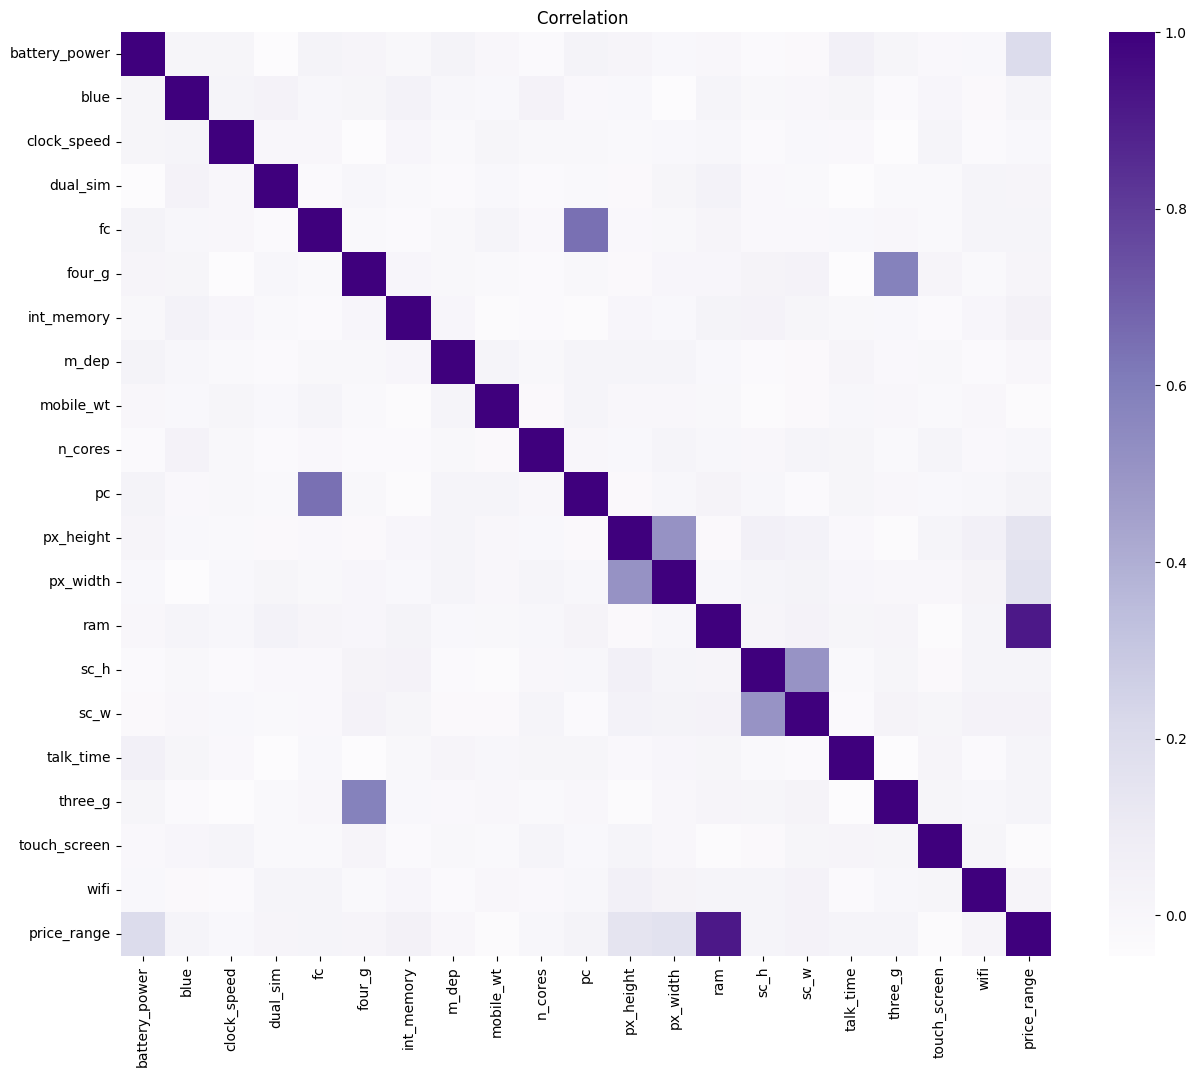

In [ ]:
#Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
corr = data_train.corr()
fig = plt.figure(figsize=(15,12))
r = sns.heatmap(corr, cmap='Purples')
r.set_title("Correlation ")

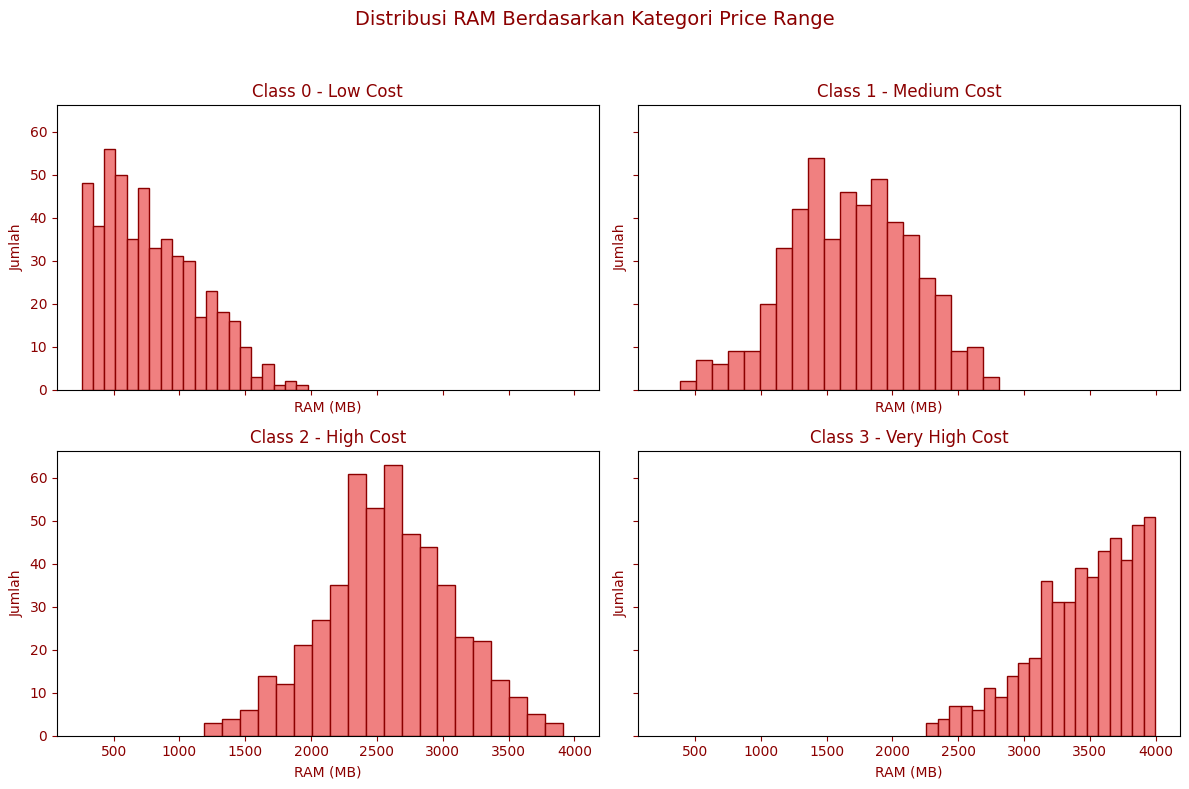

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

# Judul tiap subplot
titles = {
    0: 'Class 0 - Low Cost',
    1: 'Class 1 - Medium Cost',
    2: 'Class 2 - High Cost',
    3: 'Class 3 - Very High Cost'
}

# Plot histogram untuk masing-masing kelas price_range
for i in range(4):
    ax = axes[i//2, i%2]
    subset = data_train[data_train['price_range'] == i]
    ax.hist(subset['ram'], bins=20, color='lightcoral', edgecolor='darkred')
    ax.set_title(titles[i], color='darkred')
    ax.set_xlabel('RAM (MB)', color='darkred')
    ax.set_ylabel('Jumlah', color='darkred')
    ax.tick_params(colors='darkred')

# Judul keseluruhan
plt.suptitle('Distribusi RAM Berdasarkan Kategori Price Range', fontsize=14, color='darkred')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

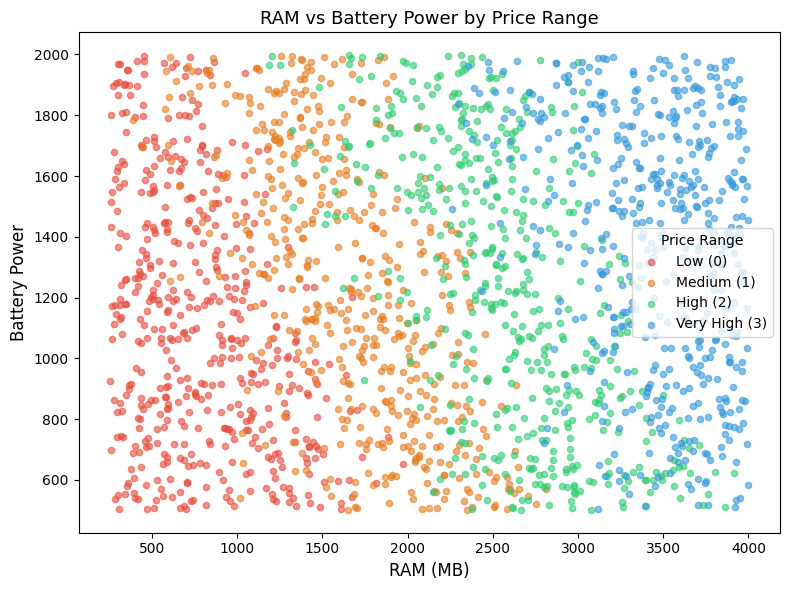

In [ ]:
# Warna untuk masing-masing kelas
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db']
labels = ['Low (0)', 'Medium (1)', 'High (2)', 'Very High (3)']

plt.figure(figsize=(8, 6))

for i in range(4):
    subset = data_train[data_train['price_range'] == i]
    plt.scatter(subset['ram'], subset['battery_power'],
                color=colors[i], label=labels[i], alpha=0.6, s=8)

plt.xlabel('RAM (MB)', fontsize=8)
plt.ylabel('Battery Power', fontsize=8)
plt.title('RAM vs Battery Power by Price Range', fontsize=13)
plt.legend(title='Price Range')
plt.tight_layout()
plt.grid(False)
plt.show()

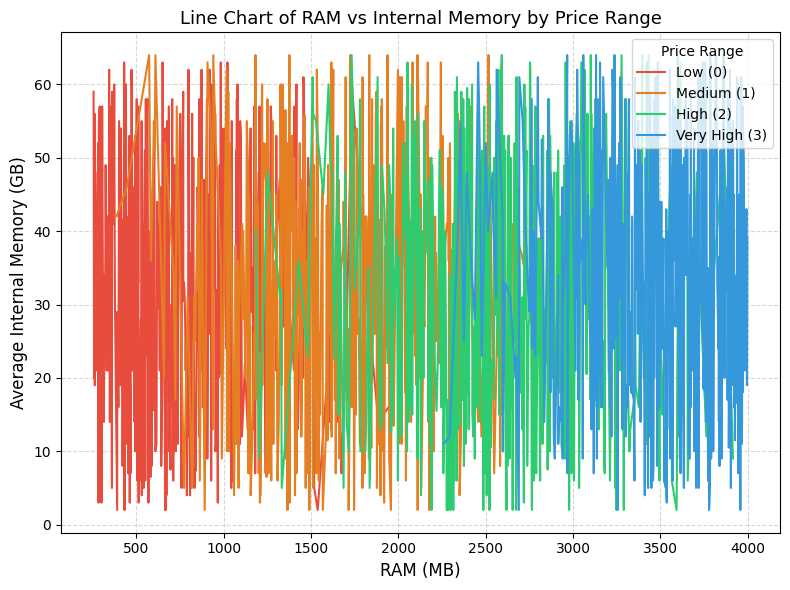

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Hitung rata-rata internal memory untuk setiap RAM pada masing-masing kelas harga
grouped = data_train.groupby(['price_range', 'ram'])['int_memory'].mean().reset_index()

# Warna dan label
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db']
labels = ['Low (0)', 'Medium (1)', 'High (2)', 'Very High (3)']

plt.figure(figsize=(8, 6))

for i in range(4):
    subset = grouped[grouped['price_range'] == i]
    plt.plot(subset['ram'], subset['int_memory'], label=labels[i],
             color=colors[i])

plt.xlabel('RAM (MB)', fontsize=12)
plt.ylabel('Average Internal Memory (GB)', fontsize=12)
plt.title('Line Chart of RAM vs Internal Memory by Price Range', fontsize=13)
plt.legend(title='Price Range')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


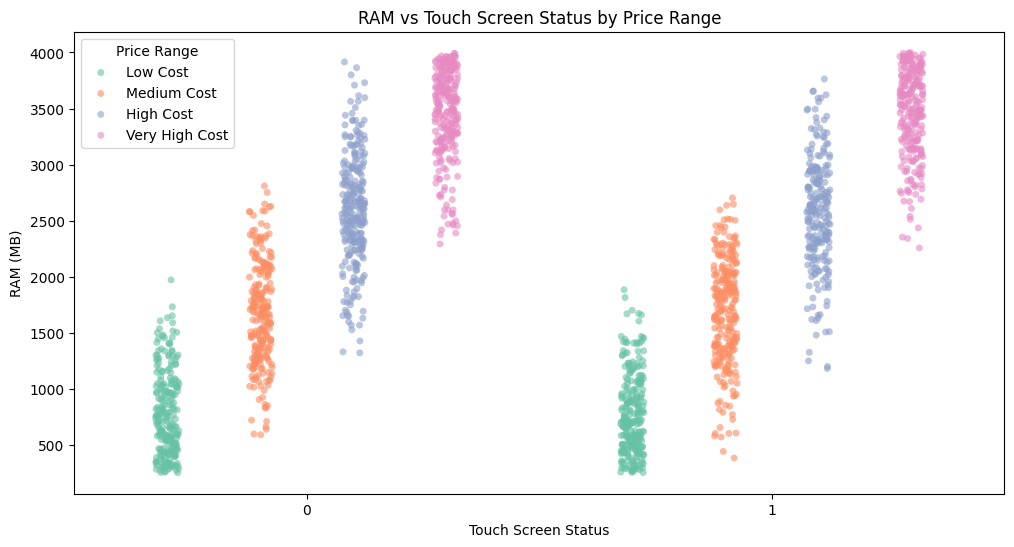

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming data_train is already loaded as a DataFrame
# Example of the structure:
# data_train = pd.read_csv('data.csv')  # or load your dataset as required

# Set up the plot
plt.figure(figsize=(12, 6))

# Plot the stripplot
sns.stripplot(x='touch_screen', y='ram', hue='price_range', data=data_train, jitter=True, dodge=True, palette='Set2', alpha=0.6)

# Add labels and title
plt.title('RAM vs Touch Screen Status by Price Range')
plt.xlabel('Touch Screen Status')
plt.ylabel('RAM (MB)')

# Show the plot
plt.legend(title='Price Range', labels=['Low Cost', 'Medium Cost', 'High Cost', 'Very High Cost'])
plt.show()


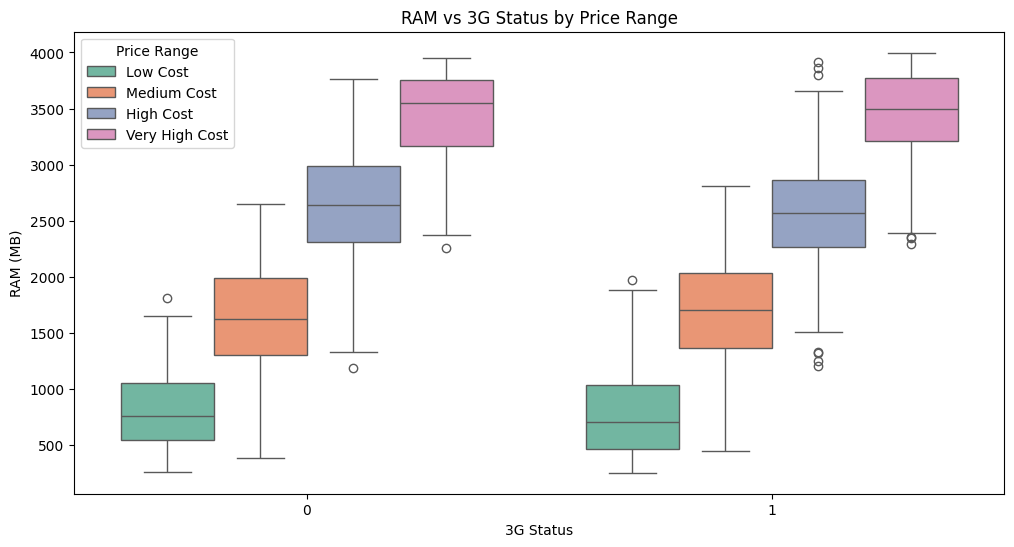

In [ ]:
# Set up the plot
plt.figure(figsize=(12, 6))

# Buat boxplot
plot = sns.boxplot(x='three_g', y='ram', hue='price_range', data=data_train, palette='Set2')

# Tambahkan label dan judul
plt.title('RAM vs 3G Status by Price Range')
plt.xlabel('3G Status')
plt.ylabel('RAM (MB)')

# Legend
handles, labels = plot.get_legend_handles_labels()
new_labels = ['Low Cost', 'Medium Cost', 'High Cost', 'Very High Cost']
plt.legend(handles=handles, labels=new_labels, title='Price Range')

# Tampilkan plot
plt.show()

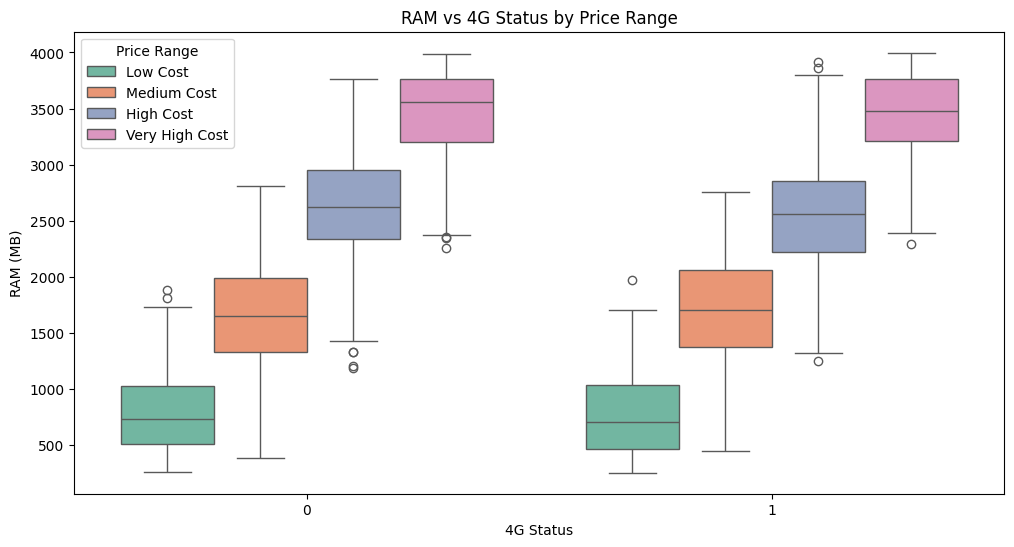

In [ ]:
plt.figure(figsize=(12, 6))

# Create the boxplot
sns.boxplot(x='four_g', y='ram', hue='price_range', data=data_train, palette='Set2')

# Add labels and title
plt.title('RAM vs 4G Status by Price Range')
plt.xlabel('4G Status')
plt.ylabel('RAM (MB)')

# Legend
handles, labels = plot.get_legend_handles_labels()
new_labels = ['Low Cost', 'Medium Cost', 'High Cost', 'Very High Cost']
plt.legend(handles=handles, labels=new_labels, title='Price Range')

# Tampilkan plot
plt.show()

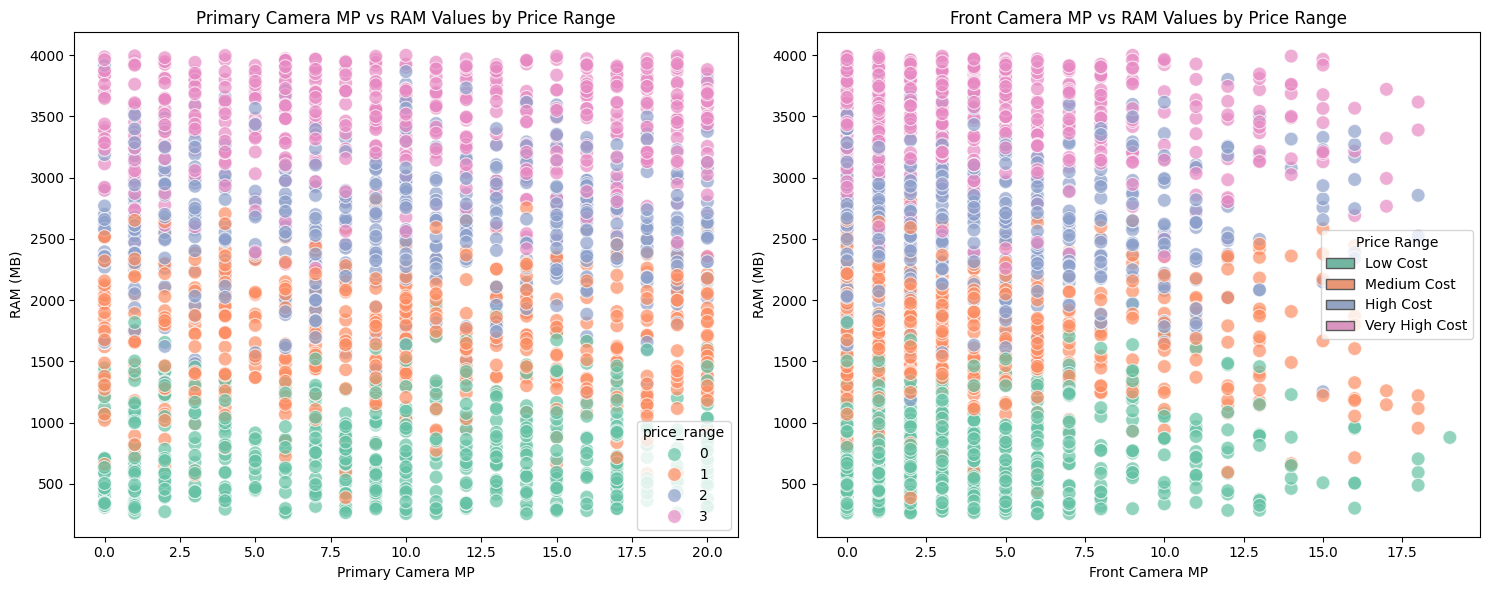

In [ ]:
# Set up the plot with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot for Primary Camera (fc) vs RAM
sns.scatterplot(x='pc', y='ram', hue='price_range', data=data_train, palette='Set2', s=100, alpha=0.7, ax=axes[0])
axes[0].set_title('Primary Camera MP vs RAM Values by Price Range')
axes[0].set_xlabel('Primary Camera MP')
axes[0].set_ylabel('RAM (MB)')

# Plot for Front Camera (pc) vs RAM
sns.scatterplot(x='fc', y='ram', hue='price_range', data=data_train, palette='Set2', s=100, alpha=0.7, ax=axes[1])
axes[1].set_title('Front Camera MP vs RAM Values by Price Range')
axes[1].set_xlabel('Front Camera MP')
axes[1].set_ylabel('RAM (MB)')

# Adjust layout for better spacing
plt.tight_layout()

# Legend
handles, labels = plot.get_legend_handles_labels()
new_labels = ['Low Cost', 'Medium Cost', 'High Cost', 'Very High Cost']
plt.legend(handles=handles, labels=new_labels, title='Price Range')

# Tampilkan plot
plt.show()

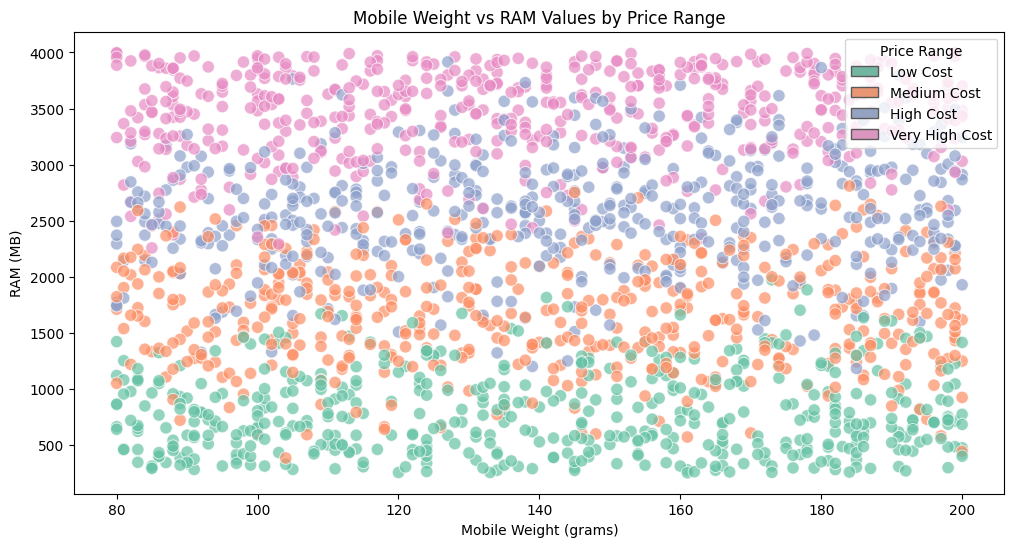

In [ ]:
# Set up the plot
plt.figure(figsize=(12, 6))

# Create the scatter plot
sns.scatterplot(x='mobile_wt', y='ram', hue='price_range', data=data_train, palette='Set2', s=80, alpha=0.7)

# Add labels and title
plt.title('Mobile Weight vs RAM Values by Price Range')
plt.xlabel('Mobile Weight (grams)')
plt.ylabel('RAM (MB)')

# Legend
handles, labels = plot.get_legend_handles_labels()
new_labels = ['Low Cost', 'Medium Cost', 'High Cost', 'Very High Cost']
plt.legend(handles=handles, labels=new_labels, title='Price Range')

plt.show()

# SVM


In [ ]:
y = data_train["price_range"].values
x_data=data_train.drop(["price_range"],axis=1)
x = (x_data-np.min(x_data))/(np.max(x_data)-np.min(x_data))
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2,random_state=1)

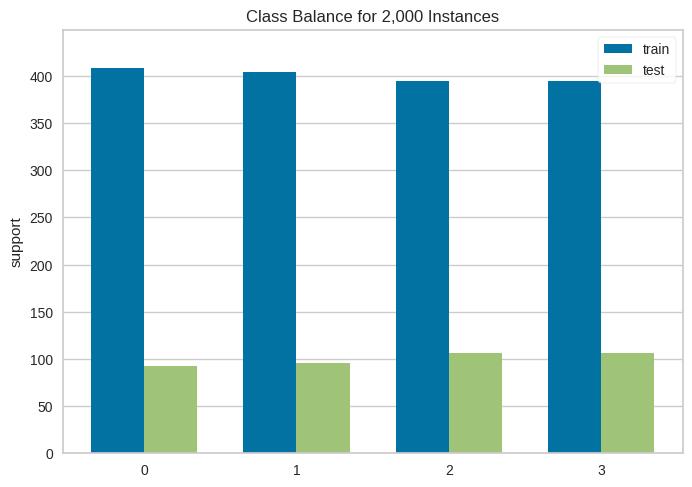

<Axes: title={'center': 'Class Balance for 2,000 Instances'}, ylabel='support'>

In [ ]:
from yellowbrick.target import ClassBalance
visualizer = ClassBalance(labels=[0, 1, 2,3])
visualizer.fit(y_train, y_test)
visualizer.poof()

In [ ]:
from sklearn.svm import SVC
svm=SVC(random_state=1)
model_awal = svm.fit(x_train,y_train)
print("train accuracy:",svm.score(x_train,y_train))
print("test accuracy:",svm.score(x_test,y_test))

train accuracy: 0.95375
test accuracy: 0.9425


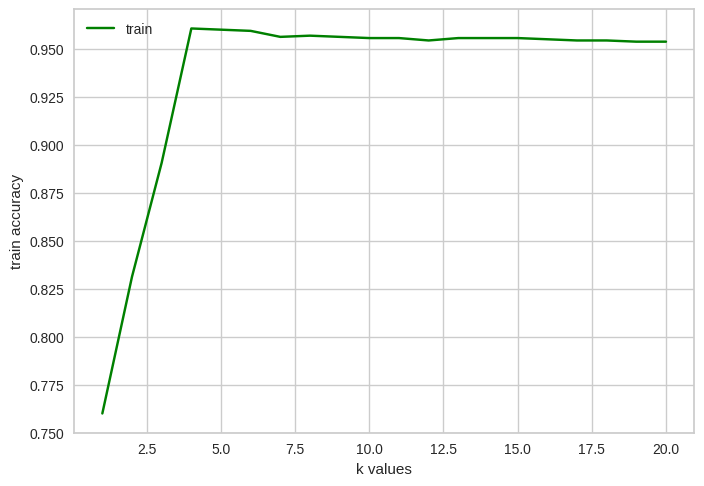

In [ ]:
#Feature Selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
accuracy_list_train = []
k=np.arange(1,21,1)
for each in k:
    x_new = SelectKBest(f_classif, k=each).fit_transform(x_train, y_train)
    svm.fit(x_new,y_train)
    accuracy_list_train.append(svm.score(x_new,y_train))

plt.plot(k,accuracy_list_train,color="green",label="train")
plt.xlabel("k values")
plt.ylabel("train accuracy")
plt.legend()
plt.show()

In [ ]:
d = {'best features number': k, 'train_score': accuracy_list_train}
df = pd.DataFrame(data=d)
print("max accuracy:",df["train_score"].max())
print("max accuracy id:",df["train_score"].idxmax())

max accuracy: 0.960625
max accuracy id: 3


In [ ]:
print(" max accuracy values: \n", df.iloc[3])

 max accuracy values: 
 best features number    4.000000
train_score             0.960625
Name: 3, dtype: float64


In [ ]:
selector = SelectKBest(f_classif, k = 4)
x_new = selector.fit_transform(x_train, y_train)
x_new_test=selector.fit_transform(x_test,y_test)
names_train = x_train.columns.values[selector.get_support()]
names_test = x_test.columns.values[selector.get_support()]
print("x train features:",names_train)
print("x test features:",names_test)


x train features: ['battery_power' 'px_height' 'px_width' 'ram']
x test features: ['battery_power' 'px_height' 'px_width' 'ram']


MODEL WITH GRIDSEARCHCV

In [ ]:
from sklearn.model_selection import GridSearchCV

C=[1,0.1,0.25,0.5,2,0.75]
kernel=["linear","rbf"]
gamma=["auto",0.01,0.001,0.0001,1]
decision_function_shape=["ovo","ovr"]

In [ ]:
svm=SVC(random_state=1)
grid_svm=GridSearchCV(estimator=svm,cv=5,param_grid=dict(kernel=kernel,C=C, gamma=gamma,
                                                         decision_function_shape=decision_function_shape))
grid_svm.fit(x_new,y_train)
print("best score: ", grid_svm.best_score_)
print("best param: ", grid_svm.best_params_)

best score:  0.9493750000000001
best param:  {'C': 2, 'decision_function_shape': 'ovo', 'gamma': 1, 'kernel': 'rbf'}


CV Score

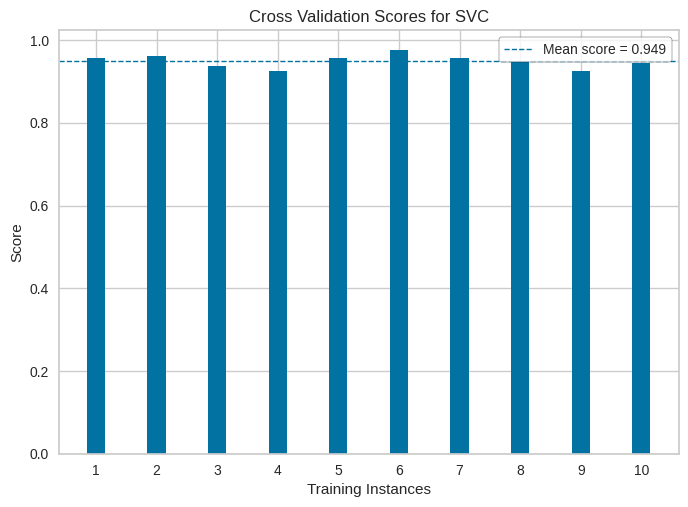

<Axes: title={'center': 'Cross Validation Scores for SVC'}, xlabel='Training Instances', ylabel='Score'>

In [ ]:
from sklearn.model_selection import StratifiedKFold
from yellowbrick.model_selection import CVScores
_, ax = plt.subplots()

# Create a cross-validation strategy
cv = StratifiedKFold(10)

# Create the cv score visualizer
oz = CVScores(
    SVC(C=2,decision_function_shape="ovo",gamma="auto",kernel="linear",random_state=1), ax=ax, cv=cv, scoring='accuracy'
)
oz.fit(x_new, y_train)
oz.poof()

Building Model

In [ ]:
svm_model=SVC(C=2,decision_function_shape="ovo",gamma="auto",kernel="linear",random_state=1)

In [ ]:
svm_model.fit(x_new,y_train)

SVC(C=2, decision_function_shape='ovo', gamma='auto', kernel='linear',
    random_state=1)

In [ ]:
print("train_accuracy:",svm_model.score(x_new,y_train))
print("test_accuracy: ", svm_model.score(x_new_test,y_test))

train_accuracy: 0.95125
test_accuracy:  0.93


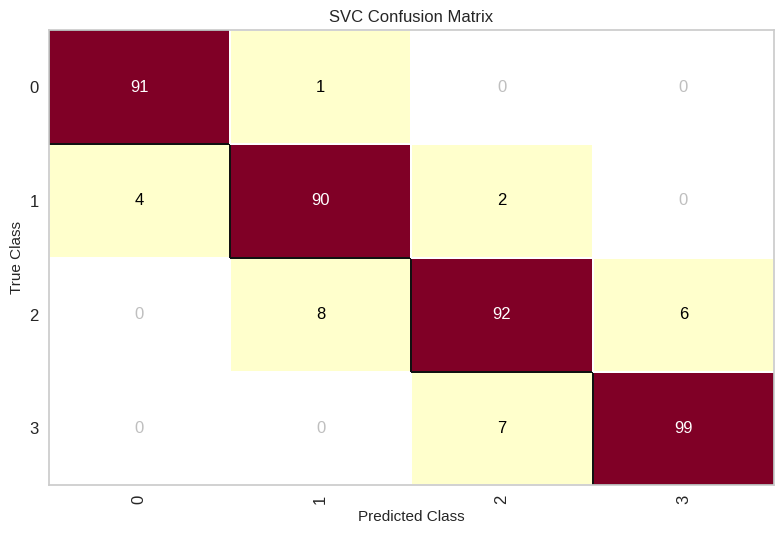

<Axes: title={'center': 'SVC Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [ ]:
#Confusion Matriks
from yellowbrick.classifier import ConfusionMatrix
cm = ConfusionMatrix(
    svm_model, classes=[0,1,2,3]
)

cm.fit(x_new, y_train)
cm.score(x_new_test, y_test)

cm.poof()

PREDICTION VISUALIZATION¶

In [ ]:
y_pred=svm_model.predict(x_new_test)

In [ ]:
svm_test=x_test[["battery_power","int_memory","px_height","px_width","ram"]]

In [ ]:
svm_test["y_true"]=y_test
svm_test["y_pred"]=y_pred

<ipython-input-29-f7c2553dd870>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  svm_test["y_true"]=y_test
<ipython-input-29-f7c2553dd870>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  svm_test["y_pred"]=y_pred


In [ ]:
svm_test.head()

,battery_power,int_memory,px_height,px_width,ram,y_true,y_pred
674,0.258629,0.011256,0.045523,0.323412,0.242371,0,0
1699,0.250625,0.011256,0.237119,0.251876,0.308654,0,0
1282,0.152326,0.002501,0.028264,0.381191,0.476488,1,1
1315,0.377689,0.008004,0.240870,0.380190,0.213607,1,0
1210,0.201351,0.014507,0.020260,0.386193,0.849675,2,3


In [ ]:
# Import necessary library
from sklearn.metrics import classification_report

# Evaluasi
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        92
           1       0.91      0.94      0.92        96
           2       0.91      0.87      0.89       106
           3       0.94      0.93      0.94       106

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



In [ ]:
#Confusion Matriks
from yellowbrick.classifier import ConfusionMatrix
cm = ConfusionMatrix(
    svm_model, classes=[0,1,2,3]
)

cm.fit(x_new, y_train)
cm.score(x_new_test, y_test)

cm.poof()